# Part 2: Beyond CIFAR-10 Image Classification

This notebook investigates how common CNN design choices affect image classification performance on the Fashion-MNIST dataset.

Four model variants are compared:

1. A baseline CNN without batch normalization
2. A CNN with batch normalization
3. A CNN with batch normalization but without dropout
4. A CNN with batch normalization and data augmentation

The experimental protocol records training loss, testing loss, training accuracy, testing accuracy, and training time.

In [11]:
# ECS7026P Neural Networks and Deep Learning
# Part 2: Beyond CIFAR-10 Image Classification
#
# Experiment: effect of batch normalization on CNN performance
# Dataset: Fashion-MNIST

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random
import time

In [12]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Dataset

Fashion-MNIST is used as the dataset for this experiment. It contains grayscale images of clothing items belonging to 10 classes. The dataset is small enough to train quickly in Google Colab, while still being suitable for image classification experiments.

In [13]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = train_dataset.classes

print("Training examples:", len(train_dataset))
print("Testing examples:", len(test_dataset))
print("Classes:", classes)

Training examples: 60000
Testing examples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Augmented training DataLoader

A second training DataLoader is created with random cropping and horizontal flipping. This is used to test whether data augmentation improves generalisation when combined with batch normalization.

In [14]:
augmented_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

augmented_train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=augmented_transform
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Augmented training examples:", len(augmented_train_dataset))

Augmented training examples: 60000


## Models

Four convolutional neural network variants are compared. The first model is a baseline CNN without batch normalization. The second model adds batch normalization. The third model keeps batch normalization but removes dropout. The fourth model uses batch normalization with data augmentation. This turns the experiment into a small ablation study of common CNN design choices.

In [15]:
class CNNWithoutBatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNWithBatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Additional ablation model: BatchNorm without Dropout

This model keeps the batch normalization layers but removes dropout from the classifier. This tests whether dropout improves generalisation or whether the BatchNorm model performs better without it.

In [16]:
class CNNWithBatchNormNoDropout(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Model sanity check

In [17]:
baseline_model = CNNWithoutBatchNorm().to(device)
batchnorm_model = CNNWithBatchNorm().to(device)
batchnorm_no_dropout_model = CNNWithBatchNormNoDropout().to(device)

fake_images = torch.randn(8, 1, 28, 28).to(device)

baseline_logits = baseline_model(fake_images)
batchnorm_logits = batchnorm_model(fake_images)
batchnorm_no_dropout_logits = batchnorm_no_dropout_model(fake_images)

print("Input shape:", fake_images.shape)
print("Baseline output shape:", baseline_logits.shape)
print("BatchNorm output shape:", batchnorm_logits.shape)
print("BatchNorm no Dropout output shape:", batchnorm_no_dropout_logits.shape)

Input shape: torch.Size([8, 1, 28, 28])
Baseline output shape: torch.Size([8, 10])
BatchNorm output shape: torch.Size([8, 10])
BatchNorm no Dropout output shape: torch.Size([8, 10])


## Training and Evaluation Functions

Both models are trained using the same training loop, optimiser, loss function, batch size, and number of epochs. This keeps the comparison fair.

In [18]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        running_total += labels.size(0)
        running_correct += (predicted == labels).sum().item()

    average_loss = running_loss / len(train_loader)
    accuracy = 100 * running_correct / running_total

    return average_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

    average_loss = running_loss / len(data_loader)
    accuracy = 100 * running_correct / running_total

    return average_loss, accuracy

## Experiment Function

The following function trains a model for a fixed number of epochs and records training loss, testing loss, training accuracy, testing accuracy, and training time.

In [19]:
def run_experiment(model_class, model_name, num_epochs=10):
    model = model_class().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = {
        "model_name": model_name,
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": [],
        "training_time": None
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = evaluate(
            model=model,
            data_loader=test_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_acc)
        history["test_accuracy"].append(test_acc)

        print(
            f"{model_name} | "
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Test Acc: {test_acc:.2f}%"
        )

    end_time = time.time()
    history["training_time"] = end_time - start_time

    return model, history

### Experiment function with custom DataLoader

This function is used for the augmented model because it needs a different training DataLoader while keeping the same testing DataLoader.

In [20]:
def run_experiment_with_loader(model_class, model_name, train_loader_used, num_epochs=10):
    model = model_class().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = {
        "model_name": model_name,
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": [],
        "training_time": None
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader_used,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = evaluate(
            model=model,
            data_loader=test_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_acc)
        history["test_accuracy"].append(test_acc)

        print(
            f"{model_name} | "
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Test Acc: {test_acc:.2f}%"
        )

    end_time = time.time()
    history["training_time"] = end_time - start_time

    return model, history

## Running the Experiments

Both models are trained for 10 epochs using the same optimiser, learning rate, batch size, and loss function.

In [21]:
num_epochs = 10

baseline_model, baseline_history = run_experiment(
    model_class=CNNWithoutBatchNorm,
    model_name="CNN without BatchNorm",
    num_epochs=num_epochs
)

CNN without BatchNorm | Epoch [1/10] Train Loss: 0.5213 Test Loss: 0.3400 Train Acc: 81.38% Test Acc: 87.45%
CNN without BatchNorm | Epoch [2/10] Train Loss: 0.3274 Test Loss: 0.2933 Train Acc: 88.16% Test Acc: 89.02%
CNN without BatchNorm | Epoch [3/10] Train Loss: 0.2814 Test Loss: 0.2789 Train Acc: 89.72% Test Acc: 89.58%
CNN without BatchNorm | Epoch [4/10] Train Loss: 0.2506 Test Loss: 0.2515 Train Acc: 90.81% Test Acc: 90.89%
CNN without BatchNorm | Epoch [5/10] Train Loss: 0.2274 Test Loss: 0.2385 Train Acc: 91.73% Test Acc: 91.15%
CNN without BatchNorm | Epoch [6/10] Train Loss: 0.2067 Test Loss: 0.2374 Train Acc: 92.40% Test Acc: 91.27%
CNN without BatchNorm | Epoch [7/10] Train Loss: 0.1915 Test Loss: 0.2252 Train Acc: 92.93% Test Acc: 91.73%
CNN without BatchNorm | Epoch [8/10] Train Loss: 0.1747 Test Loss: 0.2308 Train Acc: 93.59% Test Acc: 91.93%
CNN without BatchNorm | Epoch [9/10] Train Loss: 0.1636 Test Loss: 0.2438 Train Acc: 93.91% Test Acc: 91.66%
CNN without BatchNo

In [22]:
batchnorm_model, batchnorm_history = run_experiment(
    model_class=CNNWithBatchNorm,
    model_name="CNN with BatchNorm",
    num_epochs=num_epochs
)

CNN with BatchNorm | Epoch [1/10] Train Loss: 0.3755 Test Loss: 0.2643 Train Acc: 87.41% Test Acc: 90.61%
CNN with BatchNorm | Epoch [2/10] Train Loss: 0.2414 Test Loss: 0.2405 Train Acc: 91.31% Test Acc: 91.41%
CNN with BatchNorm | Epoch [3/10] Train Loss: 0.2038 Test Loss: 0.2174 Train Acc: 92.68% Test Acc: 91.93%
CNN with BatchNorm | Epoch [4/10] Train Loss: 0.1741 Test Loss: 0.2284 Train Acc: 93.72% Test Acc: 92.02%
CNN with BatchNorm | Epoch [5/10] Train Loss: 0.1551 Test Loss: 0.2280 Train Acc: 94.39% Test Acc: 92.06%
CNN with BatchNorm | Epoch [6/10] Train Loss: 0.1361 Test Loss: 0.2231 Train Acc: 94.99% Test Acc: 92.38%
CNN with BatchNorm | Epoch [7/10] Train Loss: 0.1175 Test Loss: 0.2312 Train Acc: 95.69% Test Acc: 92.35%
CNN with BatchNorm | Epoch [8/10] Train Loss: 0.1049 Test Loss: 0.2362 Train Acc: 96.13% Test Acc: 92.13%
CNN with BatchNorm | Epoch [9/10] Train Loss: 0.0953 Test Loss: 0.2417 Train Acc: 96.53% Test Acc: 92.40%
CNN with BatchNorm | Epoch [10/10] Train Loss:

### Additional ablation runs

Two extra models are trained to test the effect of removing dropout and adding data augmentation.

In [23]:
batchnorm_no_dropout_model, batchnorm_no_dropout_history = run_experiment(
    model_class=CNNWithBatchNormNoDropout,
    model_name="CNN with BatchNorm, no Dropout",
    num_epochs=num_epochs
)

CNN with BatchNorm, no Dropout | Epoch [1/10] Train Loss: 0.3462 Test Loss: 0.2928 Train Acc: 88.17% Test Acc: 89.73%
CNN with BatchNorm, no Dropout | Epoch [2/10] Train Loss: 0.2170 Test Loss: 0.2402 Train Acc: 92.09% Test Acc: 91.18%
CNN with BatchNorm, no Dropout | Epoch [3/10] Train Loss: 0.1745 Test Loss: 0.2309 Train Acc: 93.67% Test Acc: 91.53%
CNN with BatchNorm, no Dropout | Epoch [4/10] Train Loss: 0.1430 Test Loss: 0.2363 Train Acc: 94.84% Test Acc: 91.73%
CNN with BatchNorm, no Dropout | Epoch [5/10] Train Loss: 0.1158 Test Loss: 0.2371 Train Acc: 95.78% Test Acc: 91.91%
CNN with BatchNorm, no Dropout | Epoch [6/10] Train Loss: 0.0952 Test Loss: 0.2376 Train Acc: 96.66% Test Acc: 91.96%
CNN with BatchNorm, no Dropout | Epoch [7/10] Train Loss: 0.0769 Test Loss: 0.2640 Train Acc: 97.28% Test Acc: 91.57%
CNN with BatchNorm, no Dropout | Epoch [8/10] Train Loss: 0.0618 Test Loss: 0.2595 Train Acc: 97.83% Test Acc: 91.92%
CNN with BatchNorm, no Dropout | Epoch [9/10] Train Loss

In [24]:
batchnorm_augmented_model, batchnorm_augmented_history = run_experiment_with_loader(
    model_class=CNNWithBatchNorm,
    model_name="CNN with BatchNorm and Augmentation",
    train_loader_used=augmented_train_loader,
    num_epochs=num_epochs
)

CNN with BatchNorm and Augmentation | Epoch [1/10] Train Loss: 0.5269 Test Loss: 0.3958 Train Acc: 81.86% Test Acc: 85.21%
CNN with BatchNorm and Augmentation | Epoch [2/10] Train Loss: 0.3654 Test Loss: 0.2821 Train Acc: 86.82% Test Acc: 89.86%
CNN with BatchNorm and Augmentation | Epoch [3/10] Train Loss: 0.3251 Test Loss: 0.2684 Train Acc: 88.15% Test Acc: 90.06%
CNN with BatchNorm and Augmentation | Epoch [4/10] Train Loss: 0.3034 Test Loss: 0.2685 Train Acc: 89.02% Test Acc: 90.16%
CNN with BatchNorm and Augmentation | Epoch [5/10] Train Loss: 0.2873 Test Loss: 0.2521 Train Acc: 89.47% Test Acc: 90.65%
CNN with BatchNorm and Augmentation | Epoch [6/10] Train Loss: 0.2805 Test Loss: 0.2559 Train Acc: 89.76% Test Acc: 90.51%
CNN with BatchNorm and Augmentation | Epoch [7/10] Train Loss: 0.2703 Test Loss: 0.2346 Train Acc: 90.08% Test Acc: 91.30%
CNN with BatchNorm and Augmentation | Epoch [8/10] Train Loss: 0.2588 Test Loss: 0.2336 Train Acc: 90.50% Test Acc: 91.34%
CNN with BatchNo

## Results Summary

In [31]:
results = [
    {
        "Model": baseline_history["model_name"],
        "Best Test Accuracy (%)": max(baseline_history["test_accuracy"]),
        "Final Test Accuracy (%)": baseline_history["test_accuracy"][-1],
        "Final Test Loss": baseline_history["test_loss"][-1],
        "Training Time (seconds)": baseline_history["training_time"]
    },
    {
        "Model": batchnorm_history["model_name"],
        "Best Test Accuracy (%)": max(batchnorm_history["test_accuracy"]),
        "Final Test Accuracy (%)": batchnorm_history["test_accuracy"][-1],
        "Final Test Loss": batchnorm_history["test_loss"][-1],
        "Training Time (seconds)": batchnorm_history["training_time"]
    },
    {
        "Model": batchnorm_no_dropout_history["model_name"],
        "Best Test Accuracy (%)": max(batchnorm_no_dropout_history["test_accuracy"]),
        "Final Test Accuracy (%)": batchnorm_no_dropout_history["test_accuracy"][-1],
        "Final Test Loss": batchnorm_no_dropout_history["test_loss"][-1],
        "Training Time (seconds)": batchnorm_no_dropout_history["training_time"]
    },
    {
        "Model": batchnorm_augmented_history["model_name"],
        "Best Test Accuracy (%)": max(batchnorm_augmented_history["test_accuracy"]),
        "Final Test Accuracy (%)": batchnorm_augmented_history["test_accuracy"][-1],
        "Final Test Loss": batchnorm_augmented_history["test_loss"][-1],
        "Training Time (seconds)": batchnorm_augmented_history["training_time"]
    }
]

for result in results:
    print(result)

{'Model': 'CNN without BatchNorm', 'Best Test Accuracy (%)': 92.13, 'Final Test Accuracy (%)': 92.13, 'Final Test Loss': 0.22599769162037706, 'Training Time (seconds)': 138.92259621620178}
{'Model': 'CNN with BatchNorm', 'Best Test Accuracy (%)': 92.5, 'Final Test Accuracy (%)': 92.5, 'Final Test Loss': 0.2422249761374691, 'Training Time (seconds)': 140.97572541236877}
{'Model': 'CNN with BatchNorm, no Dropout', 'Best Test Accuracy (%)': 92.05, 'Final Test Accuracy (%)': 91.81, 'Final Test Loss': 0.3100721834203865, 'Training Time (seconds)': 140.0035936832428}
{'Model': 'CNN with BatchNorm and Augmentation', 'Best Test Accuracy (%)': 92.0, 'Final Test Accuracy (%)': 92.0, 'Final Test Loss': 0.22101081964335864, 'Training Time (seconds)': 194.50713634490967}


## Results Plots

The following plots compare four CNN variants: the baseline CNN, the BatchNorm CNN, the BatchNorm CNN without dropout, and the BatchNorm CNN trained with data augmentation.

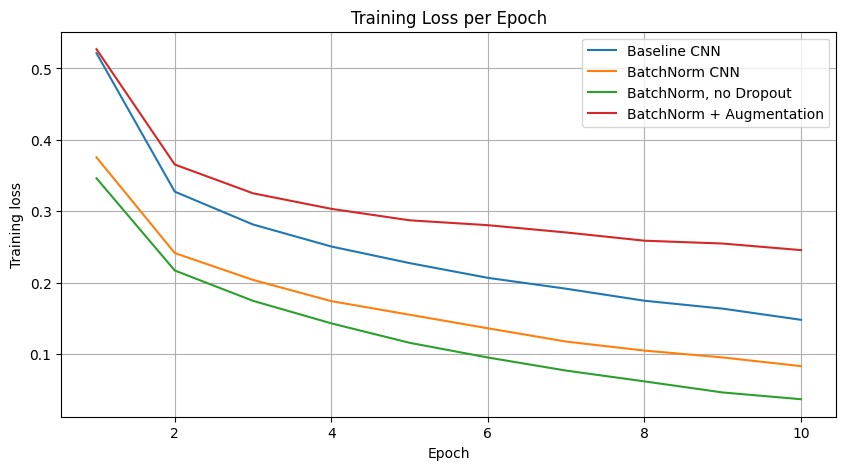

In [32]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, baseline_history["train_loss"], label="Baseline CNN")
plt.plot(epochs, batchnorm_history["train_loss"], label="BatchNorm CNN")
plt.plot(epochs, batchnorm_no_dropout_history["train_loss"], label="BatchNorm, no Dropout")
plt.plot(epochs, batchnorm_augmented_history["train_loss"], label="BatchNorm + Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

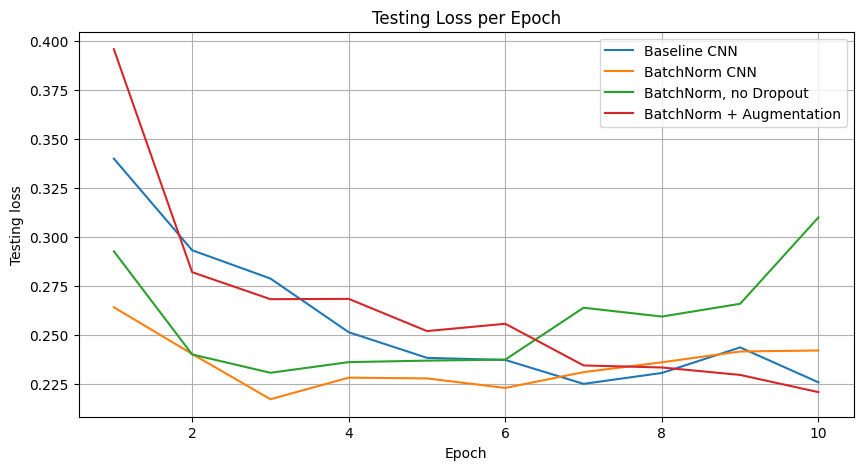

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, baseline_history["test_loss"], label="Baseline CNN")
plt.plot(epochs, batchnorm_history["test_loss"], label="BatchNorm CNN")
plt.plot(epochs, batchnorm_no_dropout_history["test_loss"], label="BatchNorm, no Dropout")
plt.plot(epochs, batchnorm_augmented_history["test_loss"], label="BatchNorm + Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Testing loss")
plt.title("Testing Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

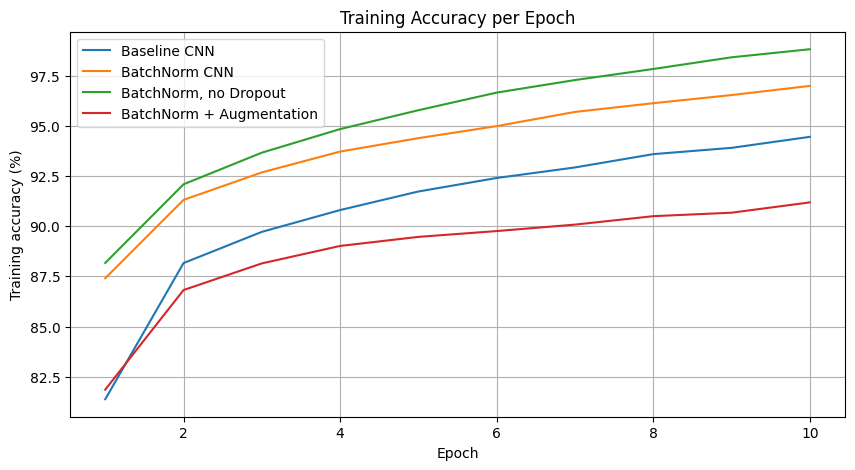

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, baseline_history["train_accuracy"], label="Baseline CNN")
plt.plot(epochs, batchnorm_history["train_accuracy"], label="BatchNorm CNN")
plt.plot(epochs, batchnorm_no_dropout_history["train_accuracy"], label="BatchNorm, no Dropout")
plt.plot(epochs, batchnorm_augmented_history["train_accuracy"], label="BatchNorm + Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Training accuracy (%)")
plt.title("Training Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

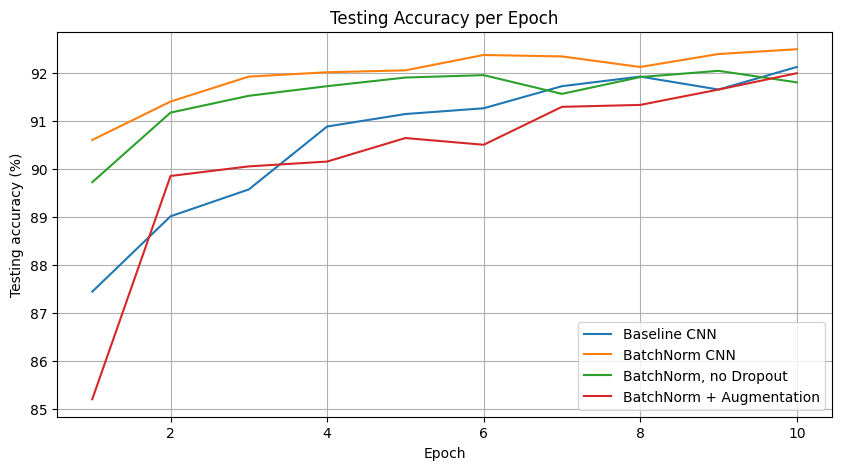

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, baseline_history["test_accuracy"], label="Baseline CNN")
plt.plot(epochs, batchnorm_history["test_accuracy"], label="BatchNorm CNN")
plt.plot(epochs, batchnorm_no_dropout_history["test_accuracy"], label="BatchNorm, no Dropout")
plt.plot(epochs, batchnorm_augmented_history["test_accuracy"], label="BatchNorm + Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Testing accuracy (%)")
plt.title("Testing Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Analysis

The updated experiment compares four CNN variants on Fashion-MNIST: a baseline CNN, a BatchNorm CNN, a BatchNorm CNN without dropout, and a BatchNorm CNN trained with data augmentation. This makes the experiment a small ablation study rather than only a two-model comparison.

The BatchNorm CNN achieved the strongest overall testing performance. It reached the highest best test accuracy among the four models, showing that batch normalization improved generalisation compared with the baseline CNN.

Removing dropout led to much higher training accuracy, reaching 98.82% by epoch 10. However, this did not improve testing accuracy. The best test accuracy for the BatchNorm model without dropout was 92.05%, and the final test accuracy dropped to 91.81%. This suggests that removing dropout increased overfitting.

The augmented BatchNorm model improved steadily across training and reached a final testing accuracy of 92.00%. However, it did not outperform the standard BatchNorm model within 10 epochs. This may be because the random cropping and horizontal flipping made the training task harder, so the augmented model may need more epochs to benefit fully from the extra variation.

Overall, the results suggest that batch normalization was the most useful change in this experiment. Dropout helped control overfitting, while data augmentation did not improve final performance within the limited 10-epoch training budget. A stronger conclusion would require repeated runs with different random seeds and longer training for the augmented model.

In [36]:
print("Final Part 2 Result")
print("-------------------")

print(f"Best baseline test accuracy: {max(baseline_history['test_accuracy']):.2f}%")
print(f"Best BatchNorm test accuracy: {max(batchnorm_history['test_accuracy']):.2f}%")
print(f"Best BatchNorm no Dropout test accuracy: {max(batchnorm_no_dropout_history['test_accuracy']):.2f}%")
print(f"Best BatchNorm + Augmentation test accuracy: {max(batchnorm_augmented_history['test_accuracy']):.2f}%")

print()
print(f"Final baseline test accuracy: {baseline_history['test_accuracy'][-1]:.2f}%")
print(f"Final BatchNorm test accuracy: {batchnorm_history['test_accuracy'][-1]:.2f}%")
print(f"Final BatchNorm no Dropout test accuracy: {batchnorm_no_dropout_history['test_accuracy'][-1]:.2f}%")
print(f"Final BatchNorm + Augmentation test accuracy: {batchnorm_augmented_history['test_accuracy'][-1]:.2f}%")

print()
print(f"Baseline training time: {baseline_history['training_time']:.2f} seconds")
print(f"BatchNorm training time: {batchnorm_history['training_time']:.2f} seconds")
print(f"BatchNorm no Dropout training time: {batchnorm_no_dropout_history['training_time']:.2f} seconds")
print(f"BatchNorm + Augmentation training time: {batchnorm_augmented_history['training_time']:.2f} seconds")

Final Part 2 Result
-------------------
Best baseline test accuracy: 92.13%
Best BatchNorm test accuracy: 92.50%
Best BatchNorm no Dropout test accuracy: 92.05%
Best BatchNorm + Augmentation test accuracy: 92.00%

Final baseline test accuracy: 92.13%
Final BatchNorm test accuracy: 92.50%
Final BatchNorm no Dropout test accuracy: 91.81%
Final BatchNorm + Augmentation test accuracy: 92.00%

Baseline training time: 138.92 seconds
BatchNorm training time: 140.98 seconds
BatchNorm no Dropout training time: 140.00 seconds
BatchNorm + Augmentation training time: 194.51 seconds
